In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/raw/Sample - Superstore.csv',
                  encoding='latin-1')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Missing values:\n", df.isnull().sum())
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df = df.drop_duplicates()
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')
df['Year']            = df['Order Date'].dt.year
df['Month']           = df['Order Date'].dt.month
df['Quarter']         = df['Order Date'].dt.quarter
df['DayOfWeek']       = df['Order Date'].dt.dayofweek
df['ShipDays']        = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin']   = df['Profit'] / df['Sales']
df['Revenue per Unit'] = df['Sales'] / df['Quantity']

df.to_csv('../data/processed/superstore_cleaned.csv', index=False)
print("✅ Cleaned data saved!")

✅ Cleaned data saved!


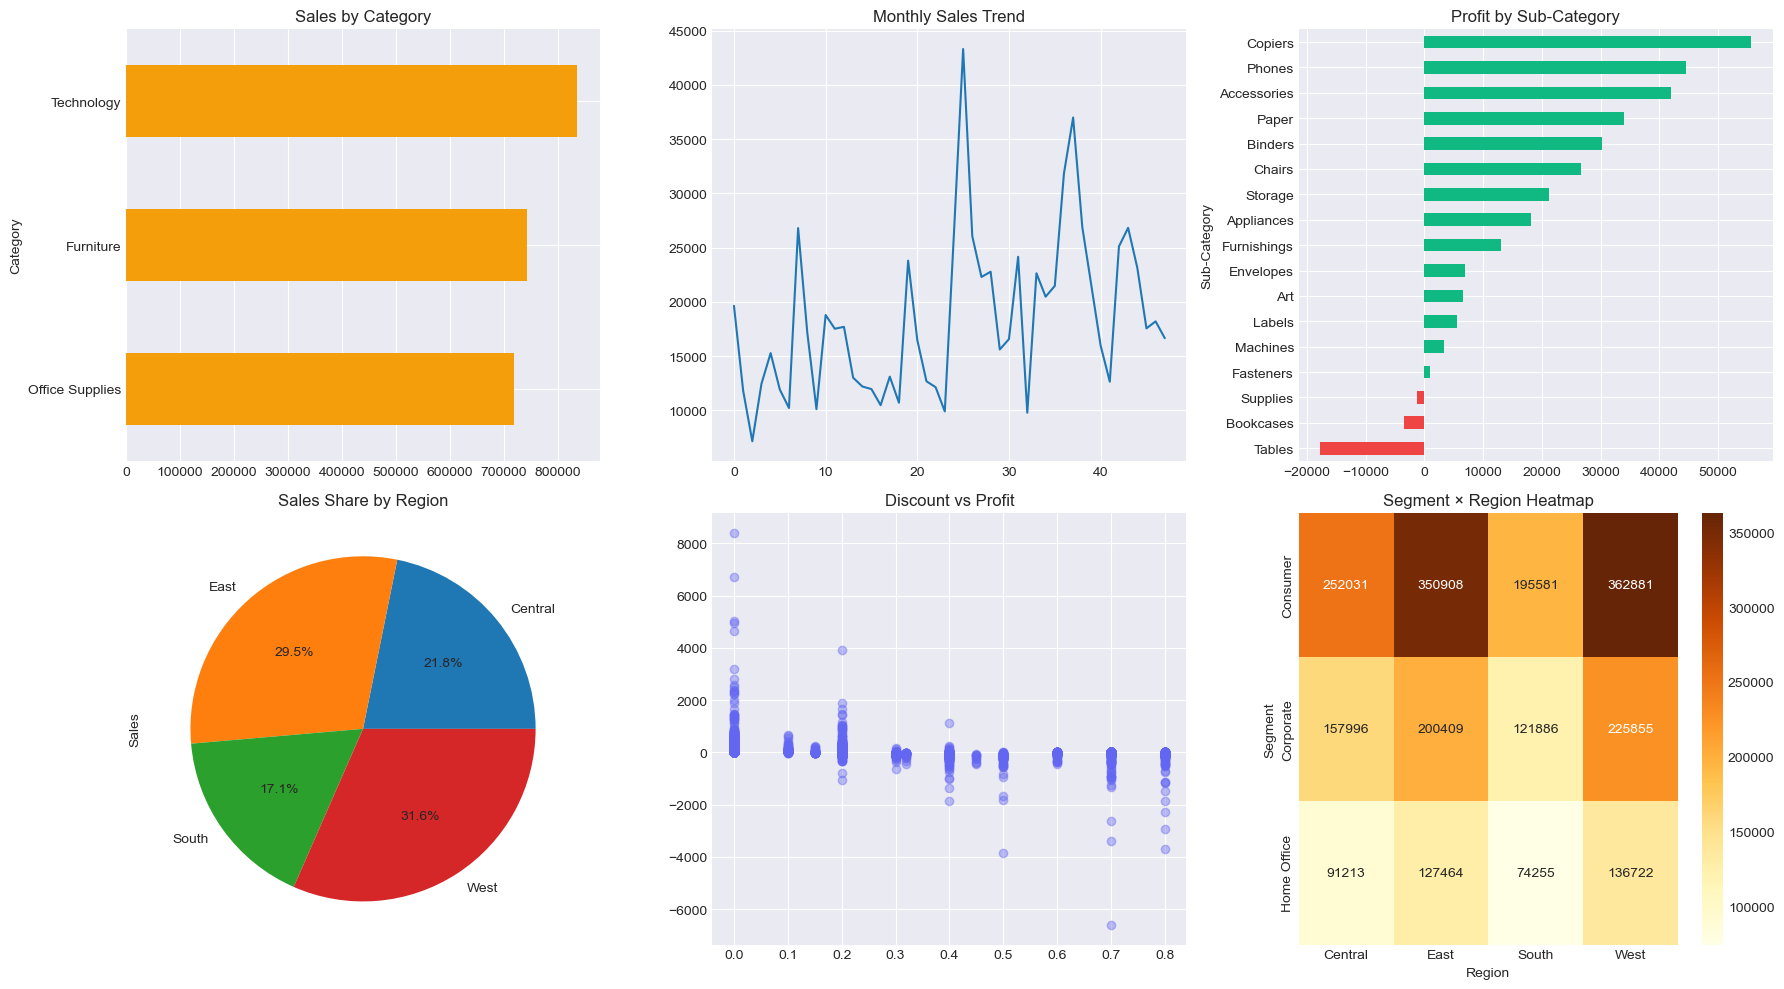

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
cat_sales.plot(kind='barh', ax=axes[0,0], color='#f59e0b')
axes[0,0].set_title('Sales by Category')

monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
axes[0,1].plot(monthly['Sales'])
axes[0,1].set_title('Monthly Sales Trend')

sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#ef4444' if x < 0 else '#10b981' for x in sub_profit]
sub_profit.plot(kind='barh', ax=axes[0,2], color=colors)
axes[0,2].set_title('Profit by Sub-Category')

df.groupby('Region')['Sales'].sum().plot(kind='pie', ax=axes[1,0],
                                             autopct='%1.1f%%')
axes[1,0].set_title('Sales Share by Region')

axes[1,1].scatter(df['Discount'], df['Profit'],
                   alpha=0.4, color='#6366f1')
axes[1,1].set_title('Discount vs Profit')

pivot = df.pivot_table(values='Sales', index='Segment',
                        columns='Region', aggfunc='sum')
sns.heatmap(pivot, ax=axes[1,2], cmap='YlOrBr', fmt='.0f', annot=True)
axes[1,2].set_title('Segment × Region Heatmap')

plt.tight_layout()
plt.savefig('../reports/eda_charts.png', dpi=150)
plt.show()